In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [3]:
kz = pd.read_csv("kase.csv")
us = pd.read_csv("us.csv")

print(f"   KZ: {kz.shape[0]} строк, {kz.shape[1]} колонок")
print(f"   US: {us.shape[0]} строк, {us.shape[1]} колонок")

   KZ: 27252 строк, 35 колонок
   US: 84277 строк, 50 колонок


In [4]:
def create_target(df):
    def label(x):
        if x > 0.02:
            return "buy"
        elif x < -0.02:
            return "sell"
        else:
            return "hold"
    
    df['target'] = df['ret_fwd_20'].apply(label)
    return df

kz = create_target(kz)
us = create_target(us)

print(f"   KZ распределение:\n{kz['target'].value_counts()}")
print(f"   US распределение:\n{us['target'].value_counts()}")

   KZ распределение:
target
hold    10397
buy      8958
sell     7897
Name: count, dtype: int64
   US распределение:
target
buy     37434
sell    29351
hold    17492
Name: count, dtype: int64


In [5]:
drop_cols = ['ticker', 'date', 'ret_fwd_20', 'label', 'threshold'] 

# Технические признаки 
tech_features = ['open', 'high', 'low', 'close', 'adj_close', 'volume',
                 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'sma_20', 'sma_50',
                 'ema_12', 'ema_26', 'price_to_sma50', 'rsi_14', 'macd', 
                 'macd_signal', 'macd_hist', 'stoch_k', 'bb_upper', 'bb_lower',
                 'bb_width', 'atr_14', 'volume_ratio_20', 'volume_roc', 'obv',
                 'overnight_gap', 'intraday_range', 'sigma_20d']

# Фундаментальные признаки (только для US)
fund_features = ['eps', 'revenue', 'revenue_growth_yoy', 'gross_margin', 
                 'operating_margin', 'net_margin', 'roe', 'debt_to_equity',
                 'current_ratio', 'fcf', 'operating_cf', 'pe_ttm', 'pb', 
                 'ps_ttm', 'days_since_report']

# Создаем копии данных
kz_tech = kz[tech_features + ['target']].copy()
us_tech = us[tech_features + ['target']].copy()
us_fund = us[fund_features + ['target']].copy()

print(f"   KZ (технические): {kz_tech.shape[0]} строк, {kz_tech.shape[1]} колонок")
print(f"   US (технические): {us_tech.shape[0]} строк, {us_tech.shape[1]} колонок")
print(f"   US (фундамент):   {us_fund.shape[0]} строк, {us_fund.shape[1]} колонок")

   KZ (технические): 27252 строк, 31 колонок
   US (технические): 84277 строк, 31 колонок
   US (фундамент):   84277 строк, 16 колонок


In [6]:
def prepare_data(df, features):
    # Удаляем строки с NaN в target
    df_clean = df.dropna(subset=['target']).copy()
    
    # Кодируем target в числа (buy=0, hold=1, sell=2)
    le = LabelEncoder()
    df_clean['target_encoded'] = le.fit_transform(df_clean['target'])
    
    X = df_clean[features].copy()
    y = df_clean['target_encoded']
    
    # Заполняем NaN в признаках медианой
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    return X_imputed, y, le

# Подготавливаем все три набора данных
Xk, yk, le_kz = prepare_data(kz_tech, tech_features)
Xu_tech, yu_tech, le_us_tech = prepare_data(us_tech, tech_features)
Xu_fund, yu_fund, le_us_fund = prepare_data(us_fund, fund_features)

print(f"   KZ: {Xk.shape[0]} строк, {Xk.shape[1]} признаков")
print(f"   US (тех): {Xu_tech.shape[0]} строк, {Xu_tech.shape[1]} признаков")
print(f"   US (фунд): {Xu_fund.shape[0]} строк, {Xu_fund.shape[1]} признаков")

   KZ: 27252 строк, 30 признаков
   US (тех): 84277 строк, 30 признаков
   US (фунд): 84277 строк, 15 признаков


In [7]:
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    Xk, yk, test_size=0.2, random_state=42, stratify=yk
)

Xu_tech_train, Xu_tech_test, yu_tech_train, yu_tech_test = train_test_split(
    Xu_tech, yu_tech, test_size=0.2, random_state=42, stratify=yu_tech
)

# Для фундаментальных данных 
Xu_fund_train, Xu_fund_test, yu_fund_train, yu_fund_test = train_test_split(
    Xu_fund, yu_fund, test_size=0.2, random_state=42, stratify=yu_fund
)

print(f"   KZ: train={Xk_train.shape[0]}, test={Xk_test.shape[0]}")
print(f"   US тех: train={Xu_tech_train.shape[0]}, test={Xu_tech_test.shape[0]}")
print(f"   US фунд: train={Xu_fund_train.shape[0]}, test={Xu_fund_test.shape[0]}")

   KZ: train=21801, test=5451
   US тех: train=67421, test=16856
   US фунд: train=67421, test=16856


In [8]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['buy', 'hold', 'sell']))
    
    return model, acc

# Модель 1: KZ (RandomForest)
model_kz = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_kz, acc_kz = train_and_evaluate(
    model_kz, Xk_train, yk_train, Xk_test, yk_test, 
    "Модель 1: KZ акции (технические признаки)"
)

# Модель 2: US технические (RandomForest)
model_us_tech = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_us_tech, acc_us_tech = train_and_evaluate(
    model_us_tech, Xu_tech_train, yu_tech_train, Xu_tech_test, yu_tech_test,
    "Модель 2: US акции (технические признаки)"
)

# Модель 3: US фундаментальные (RandomForest)
model_us_fund = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_us_fund, acc_us_fund = train_and_evaluate(
    model_us_fund, Xu_fund_train, yu_fund_train, Xu_fund_test, yu_fund_test,
    "Модель 3: US акции (фундаментальные признаки)"
)



Модель 1: KZ акции (технические признаки)
   Accuracy: 0.6777
   Classification Report:
              precision    recall  f1-score   support

         buy       0.68      0.73      0.71      1792
        hold       0.67      0.69      0.68      2080
        sell       0.68      0.61      0.64      1579

    accuracy                           0.68      5451
   macro avg       0.68      0.67      0.68      5451
weighted avg       0.68      0.68      0.68      5451


Модель 2: US акции (технические признаки)
   Accuracy: 0.5496
   Classification Report:
              precision    recall  f1-score   support

         buy       0.52      0.93      0.67      7487
        hold       0.72      0.01      0.03      3499
        sell       0.65      0.39      0.48      5870

    accuracy                           0.55     16856
   macro avg       0.63      0.44      0.39     16856
weighted avg       0.61      0.55      0.47     16856


Модель 3: US акции (фундаментальные признаки)
   Accuracy: 

In [9]:
print(f"\n{'Модель':<40} {'Accuracy':<10}")
print(f"{'KZ (технические)':<40} {acc_kz:.4f}")
print(f"{'US (технические)':<40} {acc_us_tech:.4f}")
print(f"{'US (фундаментальные)':<40} {acc_us_fund:.4f}")

best_model = max([
    ("KZ", acc_kz),
    ("US тех", acc_us_tech),
    ("US фунд", acc_us_fund)
], key=lambda x: x[1])

print(f"\n Лучшая модель: {best_model[0]} с accuracy = {best_model[1]:.4f}")


Модель                                   Accuracy  
KZ (технические)                         0.6777
US (технические)                         0.5496
US (фундаментальные)                     0.4970

 Лучшая модель: KZ с accuracy = 0.6777


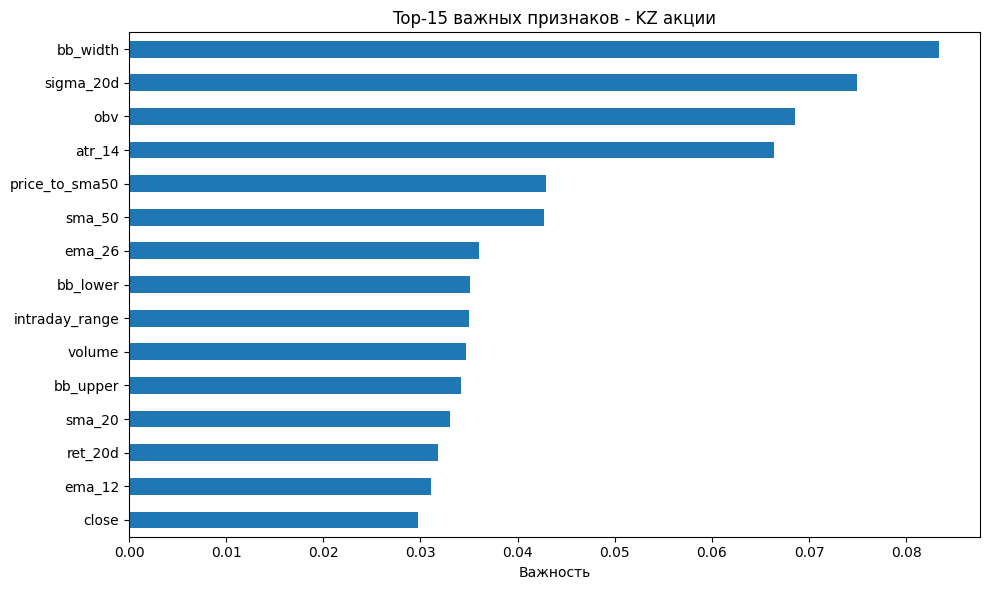

In [10]:
def plot_feature_importance(model, feature_names, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh')
    plt.xlabel('Важность')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

if best_model[0] == "KZ":
    plot_feature_importance(model_kz, Xk.columns, 
                           "Top-15 важных признаков - KZ акции")
elif best_model[0] == "US тех":
    plot_feature_importance(model_us_tech, Xu_tech.columns, 
                           "Top-15 важных признаков - US акции (технические)")
else:
    plot_feature_importance(model_us_fund, Xu_fund.columns, 
                           "Top-15 важных признаков - US акции (фундаментальные)")

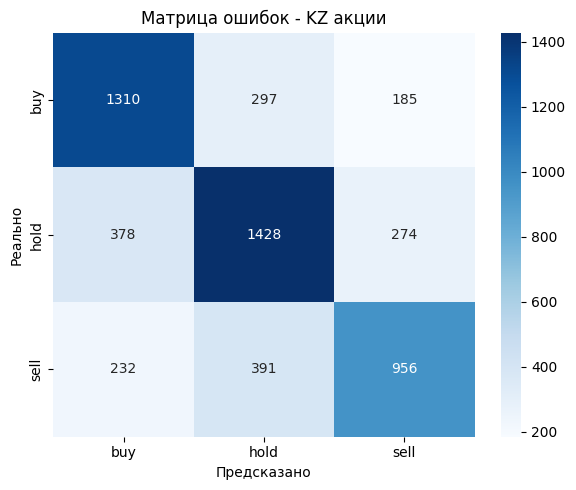

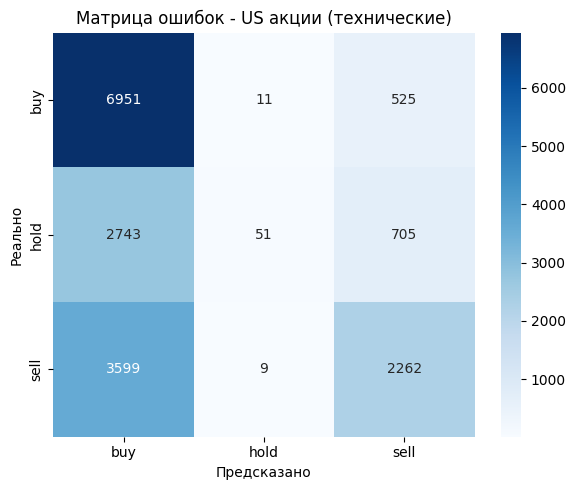

In [11]:
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['buy', 'hold', 'sell'],
                yticklabels=['buy', 'hold', 'sell'])
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model_kz, Xk_test, yk_test, 
                     "Матрица ошибок - KZ акции")
plot_confusion_matrix(model_us_tech, Xu_tech_test, yu_tech_test, 
                     "Матрица ошибок - US акции (технические)")

In [12]:
def cross_validate_model(model, X, y, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    
    print(f"\n{name}")
    print(f"   Средняя accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"   Все значения: {[f'{s:.4f}' for s in scores]}")
    return scores

print("КРОСС-ВАЛИДАЦИЯ (5 фолдов)")

cross_validate_model(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
                     Xk, yk, "KZ акции")

cross_validate_model(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
                     Xu_tech, yu_tech, "US акции (технические)")

КРОСС-ВАЛИДАЦИЯ (5 фолдов)

KZ акции
   Средняя accuracy: 0.6803 (+/- 0.0084)
   Все значения: ['0.6900', '0.6680', '0.6850', '0.6728', '0.6857']

US акции (технические)
   Средняя accuracy: 0.5493 (+/- 0.0031)
   Все значения: ['0.5451', '0.5467', '0.5501', '0.5538', '0.5506']


array([0.5450878 , 0.54668961, 0.55010383, 0.55378226, 0.55063779])